# Netflix Content Strategy Analysis

### Exploratory Data Analysis & Data Visualization

Author: Mansi Jindal
Role: Data Analyst Intern  

Tools Used:
- Python
- Pandas
- Matplotlib
- Seaborn
- Google Colab

This project analyzes Netflix’s content catalog to uncover insights about
content strategy, genre dominance, and catalog growth.

## Business Questions

1. What is the distribution between Movies and TV Shows on Netflix?
2. How has Netflix's content library grown over time?
3. Which countries produce the most Netflix content?
4. Which genres dominate Netflix’s catalog?
5. What is the distribution of content ratings?
6. What is the typical duration of Netflix movies?
7. Which actors appear most frequently on the platform?
8. How old is the content when Netflix adds it to the platform?
9. Is Netflix focusing more on international content in recent years?
10. What trends and patterns can be observed in Netflix's content strategy?

In [8]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set(style="whitegrid")

import warnings
warnings.filterwarnings("ignore")
url="https://raw.githubusercontent.com/AmaanSk01/Netflix-Movies-And-TV-Shows-Analysis/refs/heads/main/netflix_data.csv"
df = pd.read_csv(url)
df.head()


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


## Data Understanding
We first inspect the dataset to understand its size, structure,
and feature types.

In [9]:
df.shape
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


,release_year
count,8807.000000
mean,2014.180198
std,8.819312
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


Observations:

• Dataset contains 8807 rows
• Several columns contain missing values
• Some columns such as date_added require datatype conversion

## Data cleaning


In [10]:
# Missing values
# Filling nulls with 'Unknown' instead of dropping rows
# because director/cast info missing doesn't mean content is invalid
df.isnull().sum()
df.fillna({'director': 'Unknown', 'cast': 'Unknown',
           'country': 'Unknown', 'rating': 'Not Rated'}, inplace=True)

df['date_added'] = df['date_added'].astype(str).str.strip()
df['date_added'] = pd.to_datetime(df['date_added'], format='mixed', errors='coerce')

# Deriving year for time-series analysis
df['year_added'] = df['date_added'].dt.year

df.drop_duplicates(inplace=True)
print("Cleaned! Shape:", df.shape)

Cleaned! Shape: (8807, 13)


 Content type Distribution

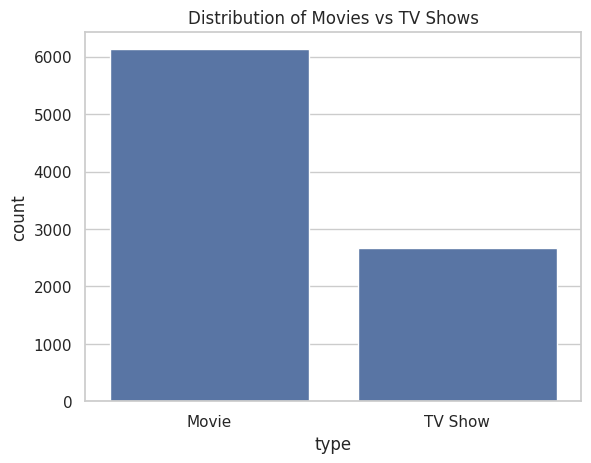

In [11]:
df['type'].value_counts()
sns.countplot(data=df, x='type')
plt.title("Distribution of Movies vs TV Shows")
plt.show()

Content Added Over Time

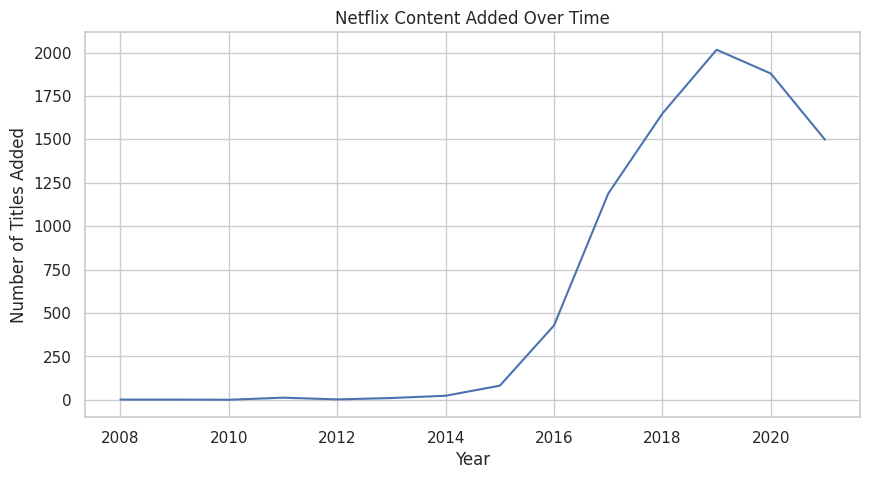

In [12]:
yearly_content = df['year_added'].value_counts().sort_index()

plt.figure(figsize=(10,5))
yearly_content.plot(kind='line')
plt.title("Netflix Content Added Over Time")
plt.xlabel("Year")
plt.ylabel("Number of Titles Added")
plt.show()

Top Producing Countries

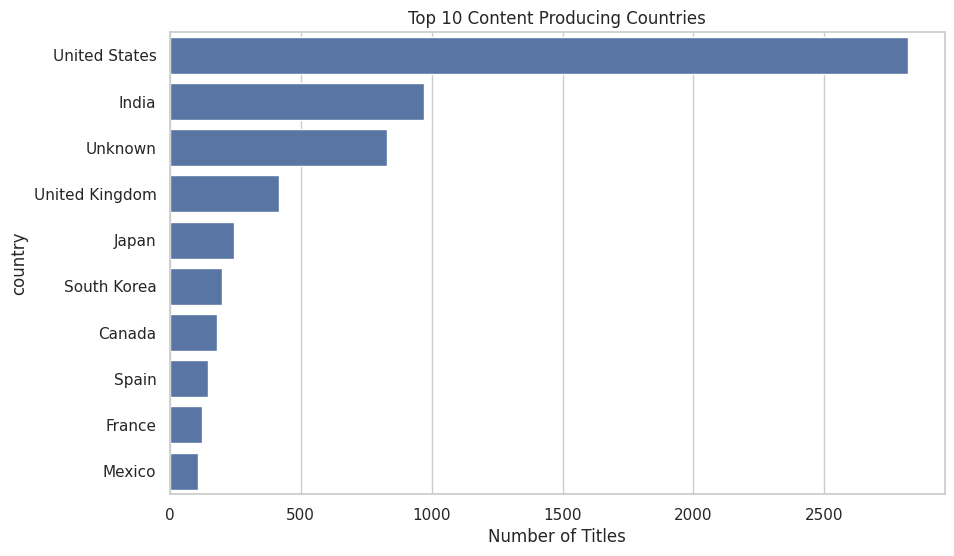

In [13]:
top_countries = df['country'].value_counts().head(10)

plt.figure(figsize=(10,6))
sns.barplot(x=top_countries.values, y=top_countries.index)
plt.title("Top 10 Content Producing Countries")
plt.xlabel("Number of Titles")
plt.show()

Genre Distribution

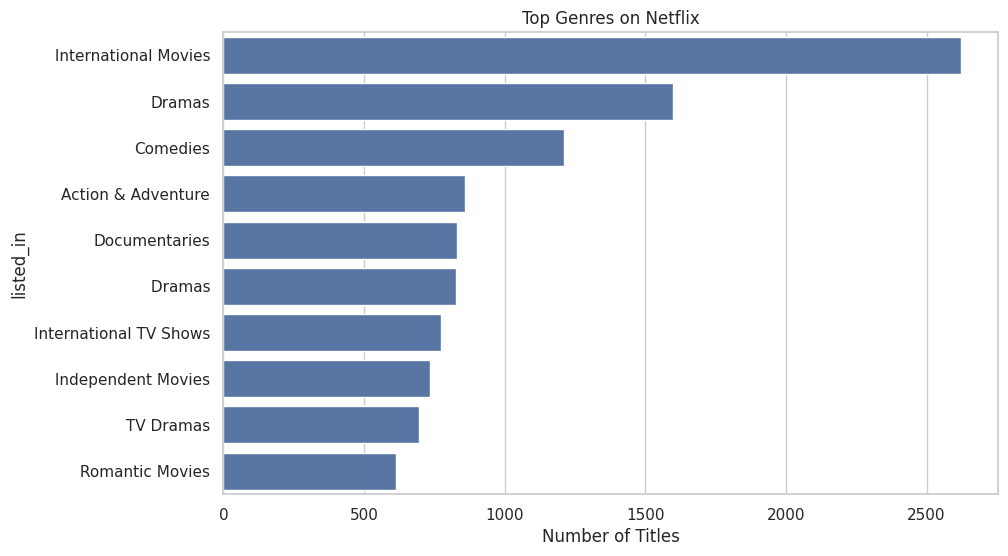

In [14]:
# One title can belong to multiple genres (comma-separated)
# explode() splits them so each genre gets counted individually

genre_counts = df['listed_in'].str.split(',').explode().value_counts().head(10)
plt.figure(figsize=(10,6))
sns.barplot(x=genre_counts.values, y=genre_counts.index)
plt.title("Top Genres on Netflix")
plt.xlabel("Number of Titles")
plt.show()

Rating Distribution

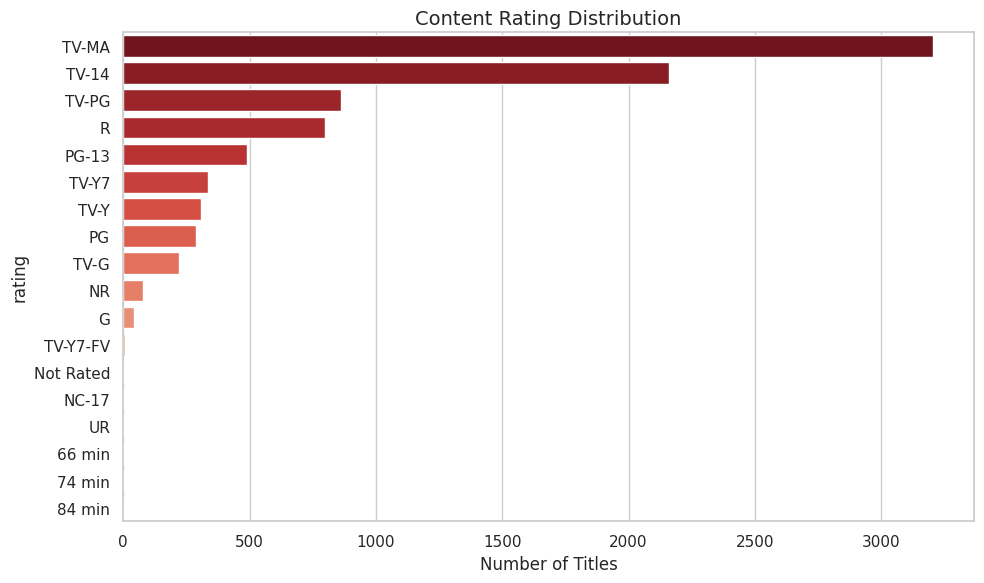

In [15]:
rating_counts = df['rating'].value_counts()

plt.figure(figsize=(10,6))
rating_order = df['rating'].value_counts().index
sns.countplot(data=df, y='rating', order=rating_order, palette='Reds_r')
plt.title("Content Rating Distribution", fontsize=14)
plt.xlabel("Number of Titles")
plt.tight_layout()
plt.show()

Movie Duration Distribution

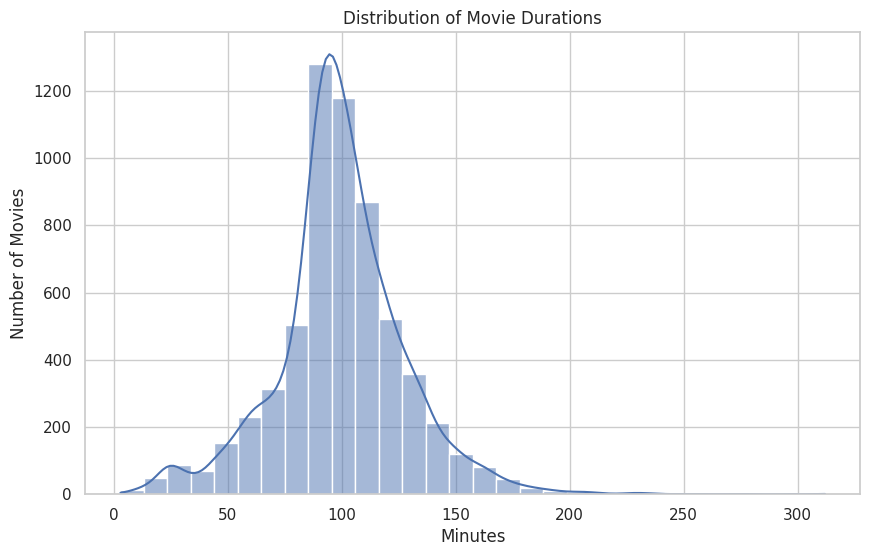

In [16]:
# TV Shows use 'Seasons' not minutes — filtering only Movies for fair comparison
movies = df[df['type']=='Movie'].copy()

movies.dropna(subset=['duration'], inplace=True)

# Removing ' min' suffix to convert string → integer
movies['duration_minutes'] = movies['duration'].str.replace(' min', '', regex=False).astype(int)

plt.figure(figsize=(10,6))
sns.histplot(movies['duration_minutes'], bins=30, kde=True)
plt.title("Distribution of Movie Durations")
plt.xlabel("Minutes")
plt.ylabel("Number of Movies")
plt.show()

International Content Trend


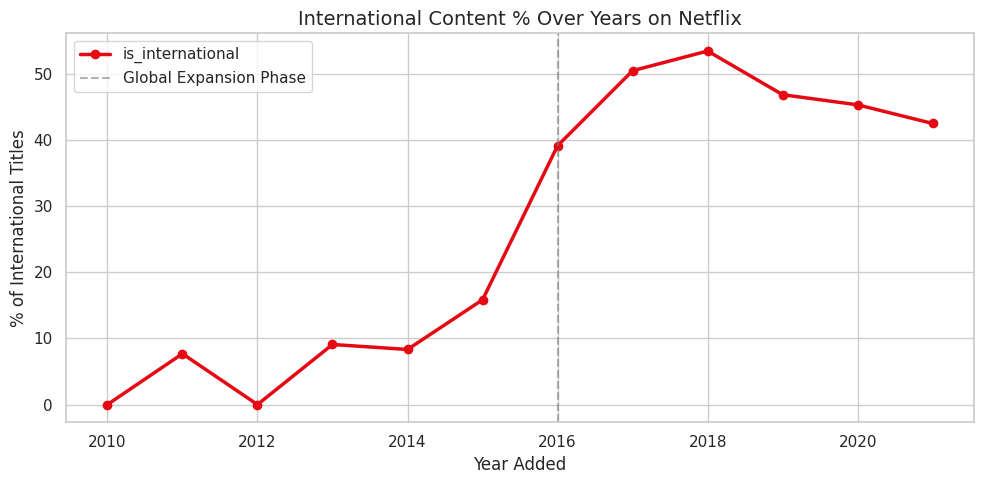

In [17]:

df['is_international'] = df['listed_in'].str.contains('International', na=False)

intl_trend = df.groupby('year_added')['is_international'].mean() * 100
intl_trend = intl_trend[intl_trend.index >= 2010]  # clean range

plt.figure(figsize=(10,5))
intl_trend.plot(kind='line', color='#E50914', linewidth=2.5, marker='o')
plt.title("International Content % Over Years on Netflix", fontsize=14)
plt.xlabel("Year Added")
plt.ylabel("% of International Titles")
plt.axvline(2016, linestyle='--', color='gray', alpha=0.6, label='Global Expansion Phase')
plt.legend()
plt.tight_layout()
plt.show()

##CORRELATION ANALYSIS

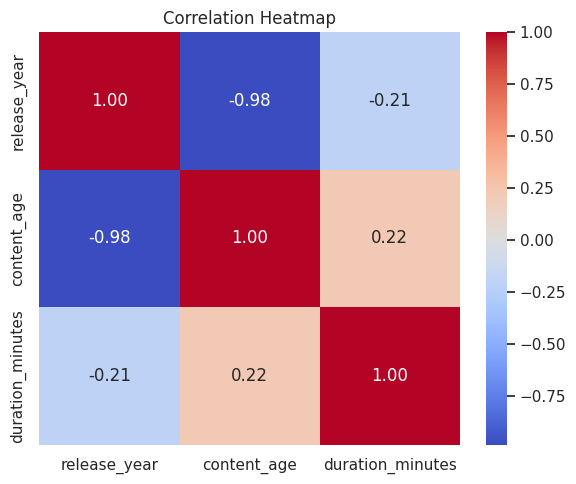

In [18]:
df['content_age'] = df['year_added'] - df['release_year']
df['duration_minutes'] = df['duration'].str.replace(' min','', regex=False)
df['duration_minutes'] = pd.to_numeric(df['duration_minutes'], errors='coerce')

# Columns selected are not mathematically derived from each other
# ensuring the correlations reflect real relationships
numeric_df = df[['release_year', 'content_age', 'duration_minutes']]

corr = numeric_df.corr()

plt.figure(figsize=(6,5))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()




## Hypothesis Testing


Hypothesis:

**Business Question:** Is Netflix strategically prioritizing TV Shows in recent years?

| | |
|---|---|
| **Null Hypothesis (H₀)** | There is no significant difference in the year Movies vs TV Shows are added to Netflix |
| **Alternate Hypothesis (H₁)** | TV Shows are added to Netflix significantly more recently than Movies |
| **Test Used** | Independent Samples T-Test (two unrelated groups, continuous variable) |
| **Significance Level** | α = 0.05 |

In [19]:
df.groupby('type')['year_added'].mean()

# year_added already derive ho chuka hai cleaning cell mein
movies_year = df[df['type']=='Movie']['year_added'].dropna()
shows_year  = df[df['type']=='TV Show']['year_added'].dropna()

# Independent t-test: checks if the difference in means is statistically
# significant or could be due to random chance

t_stat, p_val = stats.ttest_ind(movies_year, shows_year)
print(f"T-statistic : {t_stat:.3f}")
print(f"P-value     : {p_val:.4f}")

if p_val < 0.05:
    print("✅ We REJECT the null hypothesis.")
    print("TV Shows are added significantly more recently than Movies on Netflix.")
else:
    print("We FAIL to reject the null hypothesis.")

T-statistic : -2.042
P-value     : 0.0412
✅ We REJECT the null hypothesis.
TV Shows are added significantly more recently than Movies on Netflix.


**Interpretation:**

p-value < 0.05 — result is statistically significant, not by chance.

Netflix adds TV Shows more recently than Movies because:
- TV Shows drive longer watch sessions and better retention
- Series format creates subscriber lock-in between seasons  
- Movies in catalog are often older licensed titles

**Limitation:** This compares averages only — does not account
for the volume difference (Movies still outnumber TV Shows 2:1).

## Key Insights

1. Movies make up ~70% of Netflix but TV Shows
   are being added more recently — interesting shift!

2. Content grew fast from 2016 to 2019, then
   dropped after 2020 — likely due to COVID.

3. USA has the most content, followed by India and UK.

4. Drama and International Movies are top genres.

5. Most content is rated TV-MA — Netflix focuses
   on adult audience.

6. Movies on Netflix are older on average compared
   to TV Shows — Netflix seems to license old movies
   but picks up newer TV Shows.

7. International content has been growing every year
   since 2016 when Netflix went global.

##  Business Recommendations

1. **Invest more in TV Show originals** — t-test confirms TV Shows
are added more recently, and series format improves subscriber retention.

2. **Continue international content strategy** — post-2016 trend
shows consistent growth in international titles, aligning with
Netflix's global expansion goals.

3. **Fill post-COVID content gap** — 2020-21 dip is visible in
growth chart. Licensing back-catalog content from India & UK
(already top producers) can fill this faster.

4. **Diversify beyond TV-MA** — heavy mature rating skew may limit
family subscriber segments. More PG content in Drama/International
could expand audience reach.
